In [1]:
import os
import pandas as pd
from scipy.stats import pearsonr

# Path to your main data directory
data_dir = "/Users/vidhyakshayakannan/Documents/Temporal-Attention/data"

# Dictionary to store Pearson correlation per participant
participant_correlations = {}

# Dictionary to store vectors per participant
participant_vectors = {}

# Loop through each participant's directory
for participant in os.listdir(data_dir):
    participant_path = os.path.join(data_dir, participant)
    
    if os.path.isdir(participant_path):  # Ensure it's a directory
        all_data = []  # Store data from all CSV files
        
        for file in os.listdir(participant_path):
            if file.endswith(".csv"):
                file_path = os.path.join(participant_path, file)
                
                # Read CSV
                df = pd.read_csv(file_path)

                # Check if necessary columns exist
                if {"Gap", "Tone", "RT"}.issubset(df.columns):
                    all_data.append(df)

        # If we have data, process it
        if all_data:
            df = pd.concat(all_data)  # Merge all CSVs for the participant

            # Create a new DataFrame with unique Gap values
            soumAve = pd.DataFrame({'Gap': df['Gap'].unique()})

            # Compute mean RT for Tone == 1 and Tone == 2
            soumAve['InAveRT'] = soumAve['Gap'].apply(
                lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean()
            )
            soumAve['OutAveRT'] = soumAve['Gap'].apply(
                lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean()
            )

            # Drop NaN values (required for Pearson correlation)
            soumAve = soumAve.dropna()

            # Store the vectors in a dictionary
            participant_vectors[f"{participant}InAveRT"] = soumAve['InAveRT'].values
            participant_vectors[f"{participant}OutAveRT"] = soumAve['OutAveRT'].values

            # Compute Pearson correlation if we have enough data
            if len(soumAve) > 1:
                corr, _ = pearsonr(soumAve['InAveRT'], soumAve['OutAveRT'])
                participant_correlations[participant] = corr
            else:
                participant_correlations[participant] = None  # Not enough data

# Convert correlations to a DataFrame
corr_df = pd.DataFrame(list(participant_correlations.items()), columns=["Participant", "Pearson Correlation"])
print(corr_df)

# Print vectors for each participant
for key, vector in participant_vectors.items():
    print(f"{key}: {vector}")


   Participant  Pearson Correlation
0        navya             0.194887
1    manaswini             0.215799
2  mahalakshmi            -0.183652
3      soumeya            -0.001667
4        addie            -0.291635
5      richard            -0.058239
6      angelyn             0.147457
7         lila            -0.265175
8         Sree            -0.230395
navyaInAveRT: [ 996.          952.          603.          561.66666667  546.33333333
  709.33333333  690.66666667  467.          861.33333333  690.66666667
  562.66666667  583.          492.33333333  724.          747.66666667
  502.66666667  739.66666667  677.33333333  496.          357.
  404.33333333  460.66666667  590.33333333  689.33333333 1017.66666667
  647.33333333  601.66666667  630.33333333  655.          534.33333333
 2870.66666667  479.33333333  529.66666667  483.66666667  623.66666667
  649.33333333  844.33333333  723.33333333  663.66666667  595.
  742.66666667  843.          619.          594.66666667  919.66666667
  6

In [2]:
import os
import numpy as np
import pandas as pd

# Path to your main data directory
data_dir = "/Users/vidhyakshayakannan/Documents/Temporal-Attention/data"

# Dictionary to store per-participant data
participant_data = {}

# List to store all data for computing the overall average
all_data = []

# Loop through each participant's directory
for participant in os.listdir(data_dir):
    participant_path = os.path.join(data_dir, participant)

    if os.path.isdir(participant_path):  # Ensure it's a directory
        all_csvs = []  # List to store data from all CSV files for this participant

        for file in os.listdir(participant_path):
            if file.endswith(".csv"):
                file_path = os.path.join(participant_path, file)

                # Read CSV
                df = pd.read_csv(file_path)

                # Check if necessary columns exist
                if {"Gap", "Tone", "RT"}.issubset(df.columns):
                    all_csvs.append(df)

        # If data exists, process it
        if all_csvs:
            df = pd.concat(all_csvs)  # Merge all CSVs for the participant
            df = df[(df['RT'] >= 199) & (df['RT'] <= 1000)].copy()
            # Create a new DataFrame with unique Gap values
            participant_df = pd.DataFrame({'Gap': df['Gap'].unique()})
            # Compute mean RT for Tone == 1 and Tone == 2
            participant_df['InAveRT'] = participant_df['Gap'].apply(
                lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 1), 'RT'].mean()
            )
            participant_df['OutAveRT'] = participant_df['Gap'].apply(
                lambda g: df.loc[(df['Gap'] == g) & (df['Tone'] == 2), 'RT'].mean()
            )

            # Drop NaN values
            participant_df = participant_df.dropna()

            # Store participant data
            participant_data[participant] = participant_df

            # Append to overall list for averaging
            all_data.append(participant_df)

# Compute the **overall average** across all participants
if all_data:
    all_combined = pd.concat(all_data)

    # Compute overall average by Gap
    overall_avg = all_combined.groupby("Gap").mean().reset_index()

    # Display final result
    print("Overall Average RT DataFrame:")
    print(overall_avg)
else:
    print("No valid data found.")


Overall Average RT DataFrame:
    Gap     InAveRT    OutAveRT
0    50  561.833333  625.854167
1    60  540.416667  617.583333
2    70  603.333333  584.687500
3    80  608.750000  587.916667
4    90  557.000000  578.312500
5   100  487.625000  505.916667
6   110  603.777778  642.703704
7   120  602.500000  554.020833
8   130  501.812500  553.958333
9   140  604.111111  619.055556
10  150  572.520833  573.250000
11  160  580.854167  543.250000
12  170  499.111111  524.722222
13  180  589.083333  623.187500
14  190  575.925926  637.722222
15  200  492.809524  559.761905
16  210  582.203704  578.055556
17  220  563.708333  585.104167
18  230  544.611111  592.074074
19  240  505.500000  577.791667
20  250  596.708333  535.354167
21  260  478.738095  510.904762
22  270  578.020833  618.750000
23  280  553.055556  567.351852
24  290  524.937500  563.354167
25  300  525.562500  573.062500
26  310  535.476190  493.809524
27  320  587.148148  593.851852
28  330  612.481481  601.703704
29  340  5

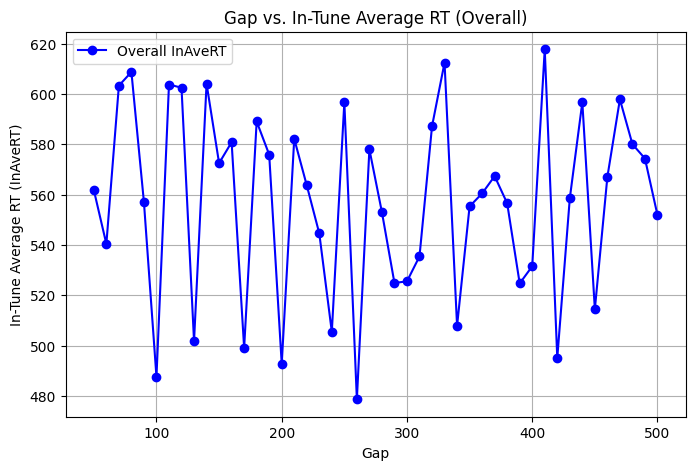

In [5]:
import matplotlib.pyplot as plt

# Plot Gap vs. InAveRT from overall_avg DataFrame
plt.figure(figsize=(8, 5))
plt.plot(overall_avg['Gap'], overall_avg['InAveRT'], marker='o', linestyle='-', color='b', label='Overall InAveRT')

# Labels and title
plt.xlabel("Gap")
plt.ylabel("In-Tune Average RT (InAveRT)")
plt.title("Gap vs. In-Tune Average RT (Overall)")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


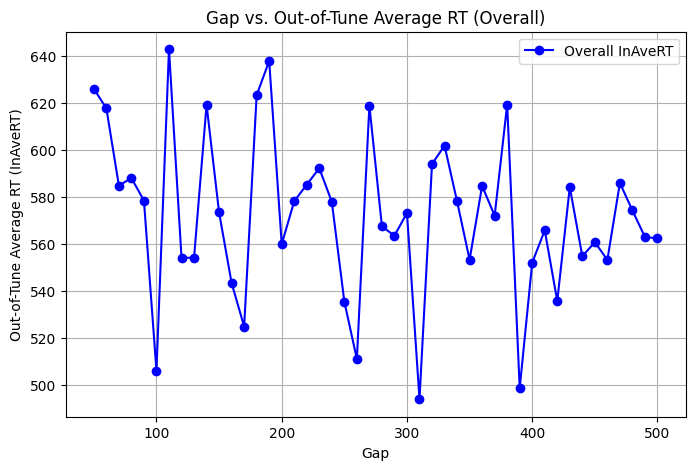

In [6]:
import matplotlib.pyplot as plt

# Plot Gap vs. InAveRT from overall_avg DataFrame
plt.figure(figsize=(8, 5))
plt.plot(overall_avg['Gap'], overall_avg['OutAveRT'], marker='o', linestyle='-', color='b', label='Overall InAveRT')

# Labels and title
plt.xlabel("Gap")
plt.ylabel("Out-of-Tune Average RT (InAveRT)")
plt.title("Gap vs. Out-of-Tune Average RT (Overall)")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [ ]:
=